In [35]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Configuration & Cleaning Map
FILE_PATH = 'PR_Crime_Summary_2010_2025.xlsx'

# Translation dictionary to standardize column headers
COLUMN_MAP = {
    'Ases.': 'Murder', 'Asesinato': 'Murder', 'Murder': 'Murder',
    'Viol.': 'Rape', 'Violacion': 'Rape', 'Rape': 'Rape',
    'Trata Humana': 'Human Trafficking', 'Human Trafficking': 'Human Trafficking',
    'Robo': 'Robbery', 'Robbery': 'Robbery',
    'Agr. Grave': 'Aggravated Assault', 'Agresion Agravada': 'Aggravated Assault', 'Aggravated Assault': 'Aggravated Assault',
    'Esc.': 'Burglary', 'Escalamiento': 'Burglary', 'Burglary': 'Burglary',
    'Apr. I': 'Larceny', 'Apropiacion Ilegal': 'Larceny', 'Larceny / Theft': 'Larceny',
    'Vehiculo Hurtado': 'Vehicle Theft', 'Vehiculo Hurtado': 'Vehicle Theft', 'Motor Vehicle Theft': 'Vehicle Theft',
    'Total': 'Total', 'TOTAL': 'Total',
    'Municipio': 'Municipality', 'MUNICIPIO': 'Municipality'
}

def clean_sheet(df, year):
    """
    Standardizes column names, adds a Year column, and removes footer totals.
    """
    # 1. Strip whitespace from column names
    df.columns = [c.strip() for c in df.columns]
    
    # 2. Rename columns using the map
    df = df.rename(columns=COLUMN_MAP)
    
    # 3. Add the year
    df['Year'] = int(year)
    
    # 4. Filter out summary rows (Total, Areas, Distritos) usually found at the bottom
    if 'Municipality' in df.columns:
        df = df[~df['Municipality'].astype(str).str.match(r'Total|Area|Distrito', case=False, na=False)]
        
        # Normalize municipality names (Title Case)
        df['Municipality'] = df['Municipality'].astype(str).str.title().str.strip()
        
    return df

In [37]:
# Cell 3: Load and Merge Data using clean_sheet function

# Prevent pandas FutureWarnings
pd.set_option('future.no_silent_downcasting', True)

all_data = []
years = range(2010, 2026) # 2010 to 2025

# Define the columns we want in our final Master Dataset
# This ensures 'Human Trafficking' is included even if missing in early sheets
desired_cols = ['Year', 'Municipality', 'Murder', 'Rape', 'Human Trafficking', 
                'Robbery', 'Aggravated Assault', 'Burglary', 'Larceny', 'Vehicle Theft']

print("Integrating yearly crime reports into the Master Dataset...")

for year in years:
    try:
        sheet_name = str(year)
        # Read raw data from the Excel sheet
        df_raw = pd.read_excel(FILE_PATH, sheet_name=sheet_name)
        
        # 1. Standardize and clean using the function from Cell 2
        df_year = clean_sheet(df_raw, year)
        
        # 2. Structural alignment: Ensure all desired columns exist
        # If a column like 'Human Trafficking' doesn't exist in that year, create it with 0
        for col in desired_cols:
            if col not in df_year.columns:
                df_year[col] = 0
        
        # 3. Append only the columns we need to the list
        all_data.append(df_year[desired_cols])
        print(f"  ✓ {year}: Integrated.")
        
    except ValueError:
        print(f"  ! Sheet '{year}' not found.")
    except Exception as e:
        print(f"  ! Error in sheet {year}: {e}")

# 4. Concatenate all years into one large DataFrame
master_df = pd.concat(all_data, ignore_index=True)

# 5. Final Data Formatting
crime_cols = ['Murder', 'Rape', 'Human Trafficking', 'Robbery', 
              'Aggravated Assault', 'Burglary', 'Larceny', 'Vehicle Theft']

# Fill any NaNs with 0 and convert crime counts to integers
master_df[crime_cols] = master_df[crime_cols].fillna(0).astype(int)

# 6. Calculate 'Total Crimes' for each row
master_df['Total Crimes'] = master_df[crime_cols].sum(axis=1)

print("\nMaster Dataset successfully generated for 2010-2025.")
master_df.head()

Integrating yearly crime reports into the Master Dataset...
  ✓ 2010: Integrated.
  ✓ 2011: Integrated.
  ✓ 2012: Integrated.
  ✓ 2013: Integrated.
  ✓ 2014: Integrated.
  ✓ 2015: Integrated.
  ✓ 2016: Integrated.
  ✓ 2017: Integrated.
  ✓ 2018: Integrated.
  ✓ 2019: Integrated.
  ✓ 2020: Integrated.
  ✓ 2021: Integrated.
  ✓ 2022: Integrated.
  ✓ 2023: Integrated.
  ✓ 2024: Integrated.
  ✓ 2025: Integrated.

Master Dataset successfully generated for 2010-2025.


,Year,Municipality,Murder,Rape,Human Trafficking,Robbery,Aggravated Assault,Burglary,Larceny,Vehicle Theft,Total Crimes
0,2010,Adjuntas,0,0,0,16,12,137,121,8,294
1,2010,Aguada,2,1,0,22,30,178,178,29,440
2,2010,Aguadilla,6,0,0,74,39,386,409,42,956
3,2010,Aguas Buenas,6,0,0,49,36,120,43,24,278
4,2010,Aibonito,4,0,0,20,48,162,194,40,468


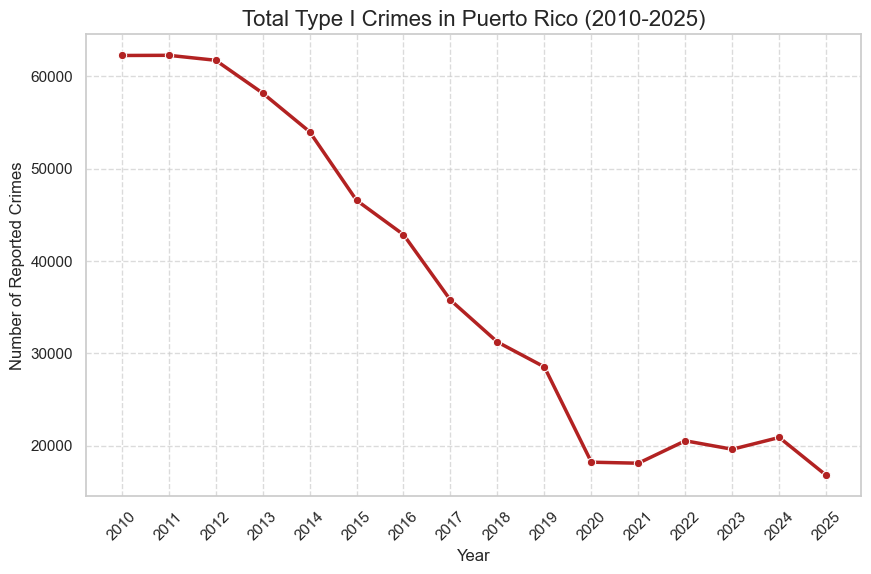

In [38]:
# Cell 4: Total Crime Trend
plt.figure(figsize=(10, 6))

yearly_totals = master_df.groupby('Year')['Total Crimes'].sum()

sns.lineplot(x=yearly_totals.index, y=yearly_totals.values, marker='o', linewidth=2.5, color='firebrick')
plt.title('Total Type I Crimes in Puerto Rico (2010-2025)', fontsize=16)
plt.ylabel('Number of Reported Crimes')
plt.xlabel('Year')
plt.xticks(yearly_totals.index, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/var/folders/ym/b3bz6k_51xx92cl9hxg3l4vr0000gn/T/ipykernel_45095/503672095.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_sums.values, y=crime_sums.index, palette='viridis')


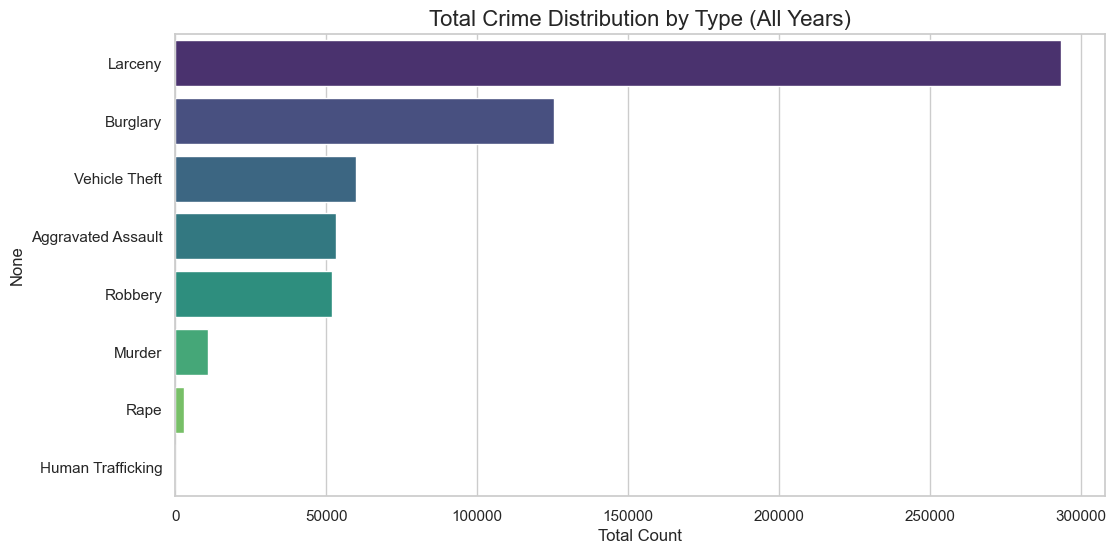

In [39]:
# Cell 5: Crime Composition
crime_sums = master_df[crime_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=crime_sums.values, y=crime_sums.index, palette='viridis')
plt.title('Total Crime Distribution by Type (All Years)', fontsize=16)
plt.xlabel('Total Count')
plt.show()

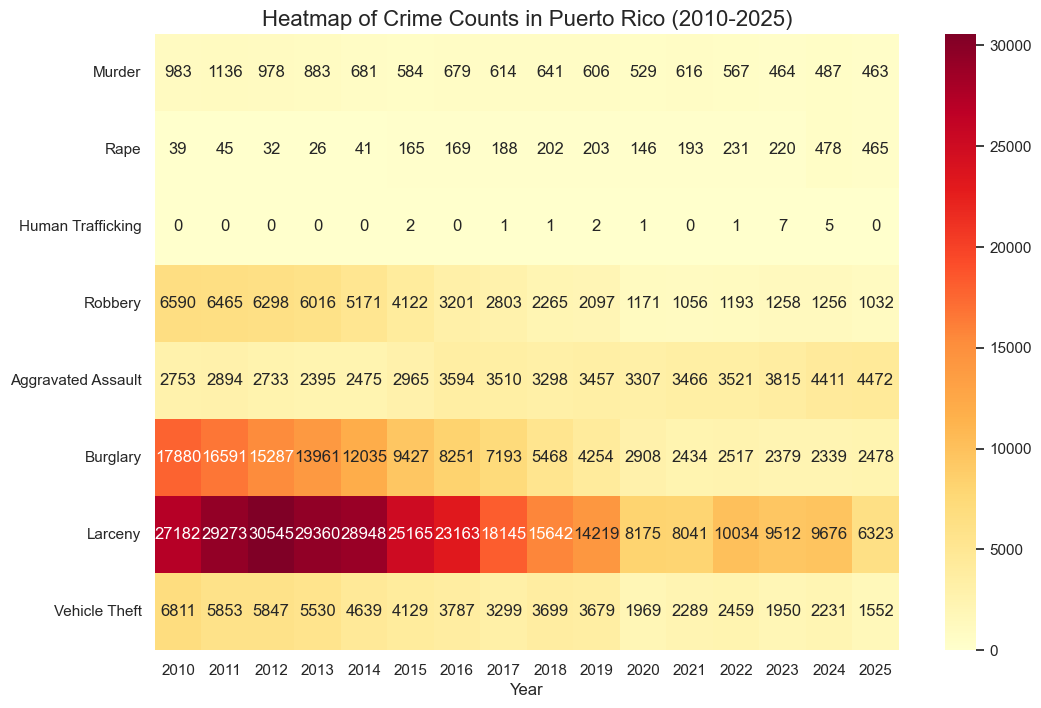

In [40]:
# New Cell: Crime Type Heatmap over Years
pivot_crime = master_df.groupby('Year')[crime_cols].sum()

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_crime.T, annot=True, fmt="d", cmap="YlOrRd")
plt.title('Heatmap of Crime Counts in Puerto Rico (2010-2025)', fontsize=16)
plt.show()

/var/folders/ym/b3bz6k_51xx92cl9hxg3l4vr0000gn/T/ipykernel_45095/3524364319.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_munis.values, y=top_munis.index, palette='magma')


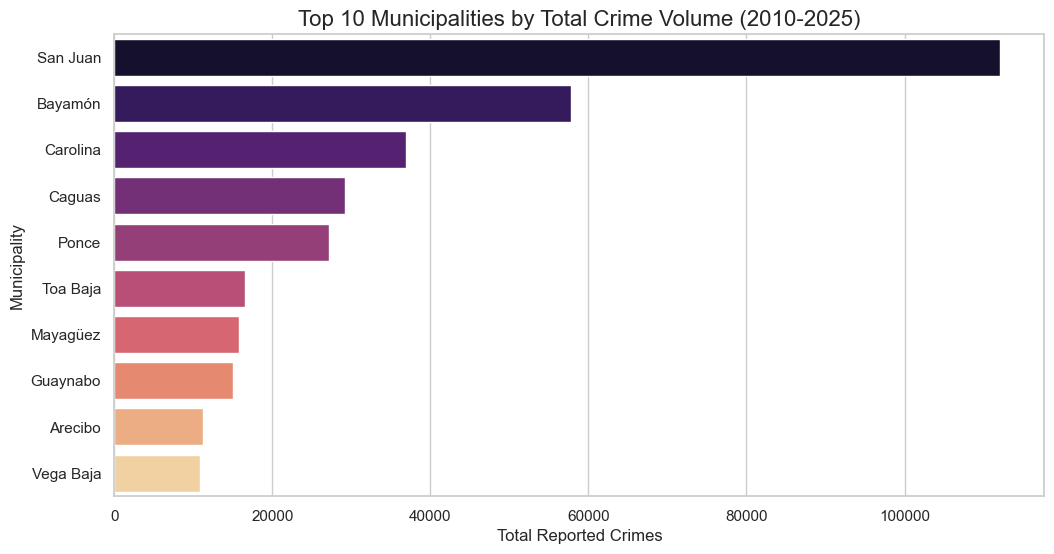

In [41]:
# Cell 6: Top 10 Municipalities with highest crime volume
top_munis = master_df.groupby('Municipality')['Total Crimes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_munis.values, y=top_munis.index, palette='magma')
plt.title('Top 10 Municipalities by Total Crime Volume (2010-2025)', fontsize=16)
plt.xlabel('Total Reported Crimes')
plt.show()

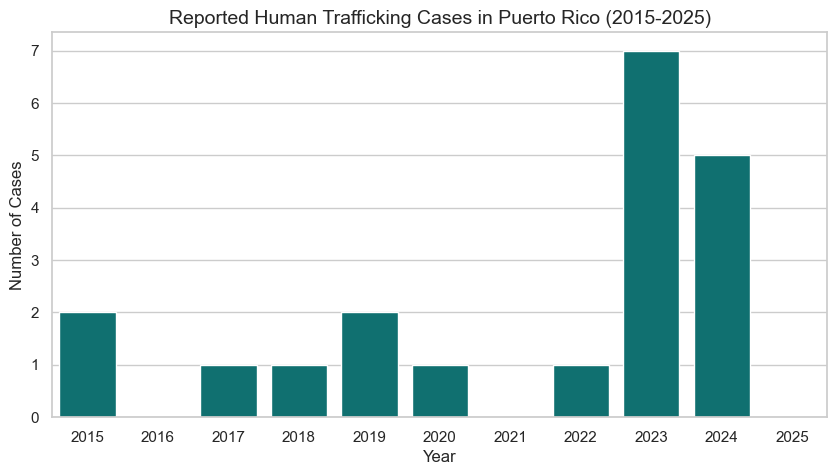

In [43]:
# Cell for Human Trafficking Analysis
ht_data = master_df[master_df['Year'] >= 2015].groupby('Year')['Human Trafficking'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=ht_data.index, y=ht_data.values, color='teal')
plt.title('Reported Human Trafficking Cases in Puerto Rico (2015-2025)', fontsize=14)
plt.ylabel('Number of Cases')
plt.show()

In [44]:
# Cell 7: Load and Display Legend
try:
    legend_df = pd.read_excel(FILE_PATH, sheet_name='Legend')
    
    # Display the legend cleanly
    # Assuming the legend has columns like "Crime Type" and "Definition"
    # We'll strip empty rows for a cleaner look
    legend_df = legend_df.dropna(how='all')
    
    pd.set_option('display.max_colwidth', None) # Show full text
    display(legend_df)
    
except Exception as e:
    print(f"Could not load Legend: {e}")

,Unnamed: 0,Unnamed: 1
0,1. Asesinato y Homicidio Voluntario,NaN
1,NaN,Definición- La muerte intencional (no negligente) de un ser humano por otro.
4,2. Violación a la Fuerza,NaN
5,NaN,"Definición- La cópula con una persona, a la fuerza y/o contra la voluntad de esa persona; o no a la"
6,NaN,fuerza o contra la voluntad de la persona cuando la víctima es incapaz de dar su consentimiento
7,NaN,debido a su incapacidad mental o física temporal o permanente (o debido a su juventud.)
9,3. Trata Humana,NaN
10,NaN,"Definición- La captación, el traslado, el transporte, la acogida o la recepción de una persona"
11,NaN,"utilizando la violencia, la amenaza, el rapto, el abuso de poder u otros elementos de coacción"
12,NaN,con el fin de someterla a la explotación sexual comercial o a la servidumbre involuntaria.


# 📊 Project Summary: Puerto Rico Crime Analysis (2010-2025)

This notebook provides a longitudinal analysis of Type I crimes across all 78 municipalities in Puerto Rico, spanning 15 years of recorded data.

### **Key Insights & Findings**
* **Overall Trend:** There is a significant downward trend in total Type I crimes from 2010 to the present. Total reported incidents have decreased significantly since the start of the decade.
* **Crime Composition:** Property crimes, specifically **Larceny (Apropiación Ilegal)** and **Burglary (Escalamiento)**, consistently represent the highest volume of reported offenses on the island.
* **High-Volume Areas:** The metropolitan areas—led by **San Juan, Bayamón, and Carolina**—account for the largest raw count of criminal activity, correlating with higher population density and commercial activity.
* **Emerging Data:** Tracking for **Human Trafficking (Trata Humana)** was integrated into the dataset starting in 2015. While the volume is low compared to other categories, the data shows a stable presence since recording began.

### **Technical Implementation**
* **Data Integration:** Successfully merged 16 separate Excel sheets (one for each year) into a single master dataset (`master_df`).
* **Standardization:** Resolved inconsistencies in reporting (Spanish vs. English headers) and handled missing data for specialized categories like Human Trafficking using automated mapping and filling logic.
* **Data Cleaning:** Filtered out aggregate summary rows (Area/Distrito) to ensure visualizations reflect only municipality-level data, preventing statistical double-counting.

### **Next Steps for Analysis**
1.  **Normalization:** Integrate SVI (Social Vulnerability Index) data to calculate **Crime Rates per 100,000 residents**. This is a crucial "Data Science" step to reveal high-intensity zones in smaller municipalities that are hidden by raw volume counts.
2.  **Socioeconomic Correlation:** Analyze the statistical relationship between poverty levels (`pct_below_poverty`) and specific crime types to identify root causes.
3.  **Spatial Analysis:** Use geographic coordinates to generate a heatmap of Puerto Rico, identifying regional clusters of activity over time.